Generating localized retail e-commerce transactional database matrices...

Executing data auditing and preprocessing workflows...
Audited missing transaction customer profiles: 29
Calculated Core Portfolio Revenue Generation: $247,459.68
Verified Unique Transacting Consumers: 150

Processing deep retail segmentation metrics...

--- Corporate Revenue Shares by Category ---
         category  gross_revenue  revenue_share_%
         Clothing       62278.28        25.167041
Sports & Outdoors       57625.88        23.286977
           Beauty       52034.43        21.027438
   Home & Kitchen       39182.64        15.833949
      Electronics       36338.45        14.684594

--- Consumer Spending Segment Matrix Sizes ---
spend_segment
Low-Value Spend    38
VIP High-Value     38
Mid-Low Spend      37
Mid-High Spend     37
Name: count, dtype: int64

Extracting cross-selling combination trends via Market Basket Association analysis...

--- Top 5 Automated Market Basket Bundling Opportunities ---


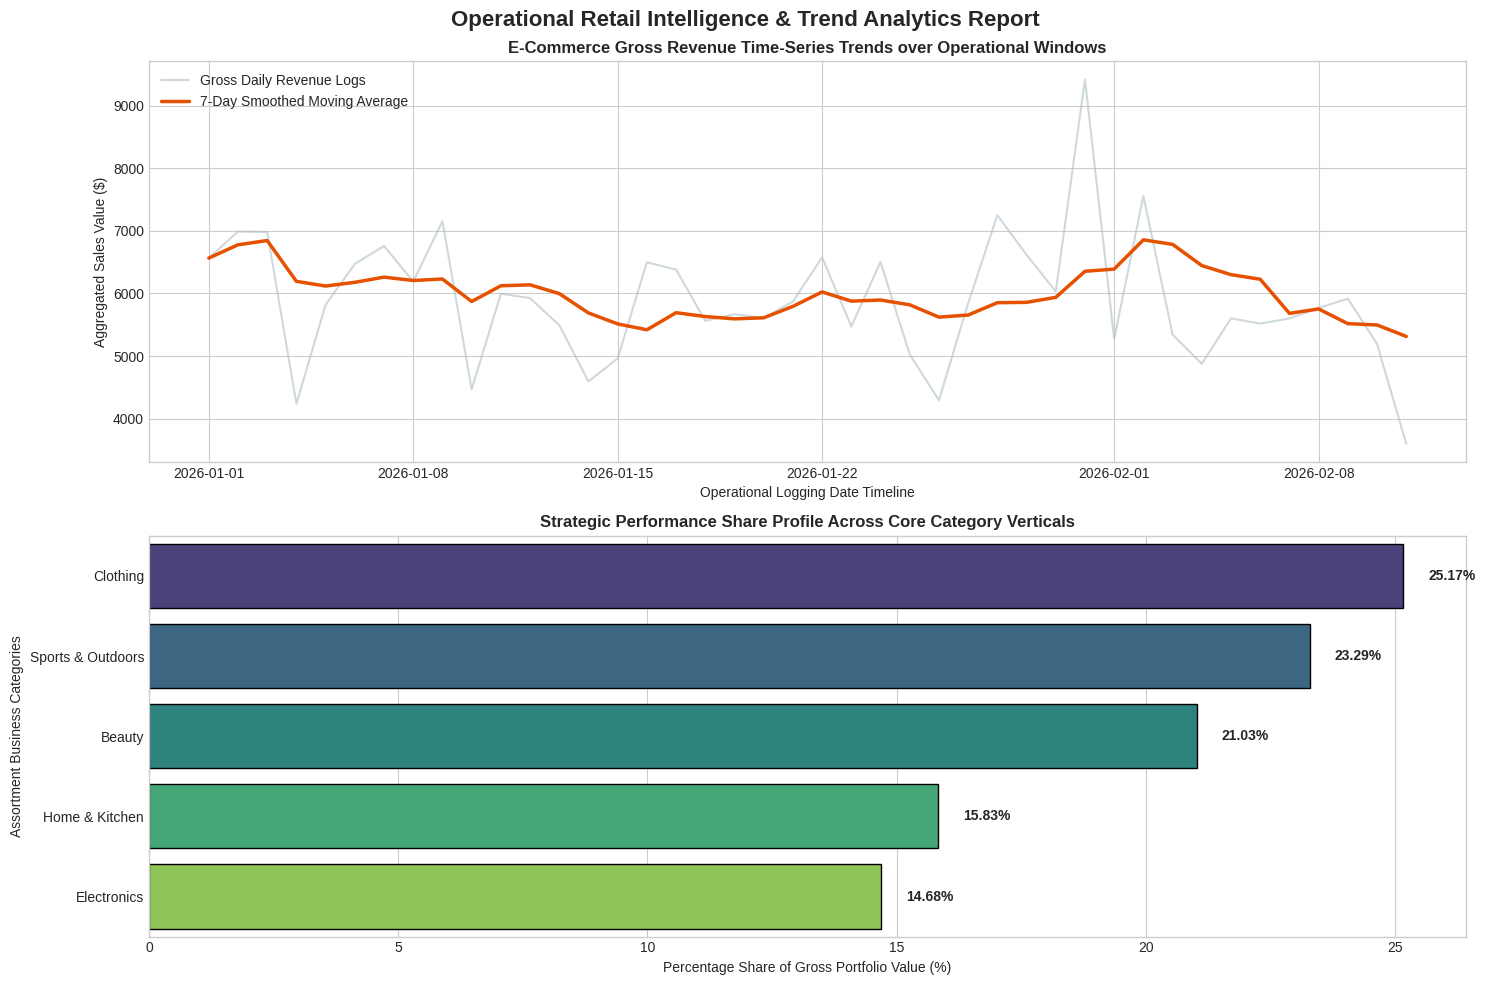

In [1]:
import itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress operational warning flags for clean readout streaming [00:35]
import warnings
warnings.filterwarnings('ignore')

# Set plotting style parameters
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'ggplot')


# ==========================================
# PART 1: SIMULATED E-COMMERCE TRANSACTION LOG ENGINE
# ==========================================
print("Generating localized retail e-commerce transactional database matrices...") # [05:49]

np.random.seed(42)
orders_count = 1000
unique_products = 50
unique_customers = 150

# 1. Structural Product Catalog Configuration Matrix [04:30]
catalog_data = {
    'product_id': [f'PROD_{str(i).zfill(3)}' for i in range(1, unique_products + 1)],
    'category': np.random.choice(['Electronics', 'Clothing', 'Home & Kitchen', 'Beauty', 'Sports & Outdoors'], size=unique_products),
    'unit_price': np.round(np.random.uniform(10.0, 250.0, size=unique_products), 2)
}
df_catalog = pd.DataFrame(catalog_data)

# 2. Generative Customer Orders Activity Engine [05:49]
orders_data = {
    'order_id': np.random.randint(10000, 10000 + orders_count, size=orders_count),
    'customer_id': [f'CUST_{str(np.random.randint(1, unique_customers + 1)).zfill(3)}' for _ in range(orders_count)],
    'product_id': np.random.choice(df_catalog['product_id'], size=orders_count),
    'quantity': np.random.choice([1, 2, 3, 4, 5], size=orders_count, p=[0.5, 0.25, 0.15, 0.07, 0.03]),
    'order_date': pd.date_range(start='2026-01-01', periods=orders_count, freq='h') # [06:00]
}
df_orders = pd.DataFrame(orders_data)

# Inject minor structural tracking gaps to practice data cleansing [15:11]
df_orders.loc[np.random.choice(orders_count, 30), 'customer_id'] = np.nan


# ==========================================
# PART 2: DATA PREPROCESSING & DATA INTEGRITY FIXES
# ==========================================
print("\nExecuting data auditing and preprocessing workflows...") # [15:11]

# Review missing tracking values [15:11]
missing_cust = df_orders['customer_id'].isna().sum()
print(f"Audited missing transaction customer profiles: {missing_cust}") # [16:01]

# Clear missing indices carefully before executing customer grouping functions [15:11, 16:22]
df_orders_clean = df_orders.dropna(subset=['customer_id']).copy()

# Enrich transaction logs by joining catalog metadata structures [08:38]
df_retail = pd.merge(df_orders_clean, df_catalog, on='product_id', how='left')

# CRITICAL BUSINESS STEP: Multiply volume parameters by unit costs to accurately state gross values [02:46, 15:47]
# (Beginners often mistake raw row counts or naked sums for final revenue metrics) [01:18, 16:22]
df_retail['gross_revenue'] = df_retail['quantity'] * df_retail['unit_price'] # [02:46, 15:55]

total_gross = df_retail['gross_revenue'].sum()
unique_buyers = df_retail['customer_id'].nunique() # [03:41]

print(f"Calculated Core Portfolio Revenue Generation: ${total_gross:,.2f}") # [02:46, 03:00]
print(f"Verified Unique Transacting Consumers: {unique_buyers}") # [03:41, 03:50]


# ==========================================
# PART 3: ADVANCED PERFORMANCE SEGMENTATION ANALYSIS
# ==========================================
print("\nProcessing deep retail segmentation metrics...")

# 1. Core Corporate Category Revenue Breakdown [08:38]
category_summary = df_retail.groupby('category')['gross_revenue'].sum().sort_values(ascending=False).reset_index() # [09:03]
category_summary['revenue_share_%'] = (category_summary['gross_revenue'] / total_gross) * 100 # [19:19]
print("\n--- Corporate Revenue Shares by Category ---") # [19:24]
print(category_summary.to_string(index=False)) # [19:38]

# 2. Strategic Consumer Spend Profiling Using Quantile Clustering [09:40, 17:22]
customer_spend = df_retail.groupby('customer_id')['gross_revenue'].sum().reset_index() # [09:40]
customer_spend['spend_segment'] = pd.qcut(customer_spend['gross_revenue'], q=4,
                                          labels=['Low-Value Spend', 'Mid-Low Spend', 'Mid-High Spend', 'VIP High-Value']) # [17:22]
print("\n--- Consumer Spending Segment Matrix Sizes ---") # [17:34]
print(customer_spend['spend_segment'].value_counts()) # [17:44]


# ==========================================
# PART 4: BASKET DENSITY ASSOCIATION (MARKET BASKET CORRELATION)
# ==========================================
print("\nExtracting cross-selling combination trends via Market Basket Association analysis...") # [11:59, 13:52]

# Aggregate items into logical transaction cart sets [13:52]
baskets = df_retail.groupby('order_id')['category'].apply(set).tolist()

# Count distinct item pairings [13:52]
pair_counts = {}
for basket in baskets:
    if len(basket) > 1:
        # Evaluate distinct multi-item pairings within specific loops [14:06]
        for pair in itertools.combinations(sorted(basket), 2):
            pair_counts[pair] = pair_counts.get(pair, 0) + 1

df_pairs = pd.DataFrame(list(pair_counts.items()), columns=['Product Pair Combo', 'Co-Purchase Frequency Count'])
df_pairs = df_pairs.sort_values(by='Co-Purchase Frequency Count', ascending=False).reset_index(drop=True)
print("\n--- Top 5 Automated Market Basket Bundling Opportunities ---") # [14:14, 14:23]
print(df_pairs.head(5)) # [14:34]


# ==========================================
# PART 5: TIME-SERIES VISUALIZATION DASHBOARD
# ==========================================
print("\nGenerating final production trends visualization charts...") # [18:14]

# Group sales metrics onto standard daily timelines [07:06]
df_retail['date_day'] = df_retail['order_date'].dt.date
daily_sales = df_retail.groupby('date_day')['gross_revenue'].sum().reset_index().sort_values('date_day') # [07:06]

# Smooth extreme daily volume variances with a rolling 7-day window moving average calculation [20:16]
daily_sales['rolling_7d_average'] = daily_sales['gross_revenue'].rolling(window=7, min_periods=1).mean() # [20:16]

# Draw dual dashboard presentation plots
fig, axes = plt.subplots(2, 1, figsize=(15, 10))
fig.suptitle('Operational Retail Intelligence & Trend Analytics Report', fontsize=16, fontweight='bold')

# Plot A: Gross Revenue Time-Series and Moving Average Smoothing Trends [18:14]
axes[0].plot(daily_sales['date_day'], daily_sales['gross_revenue'], color='#B0BEC5', alpha=0.6, label='Gross Daily Revenue Logs')
axes[0].plot(daily_sales['date_day'], daily_sales['rolling_7d_average'], color='#E65100', lw=2.5, label='7-Day Smoothed Moving Average') # [20:16]
axes[0].set_title('E-Commerce Gross Revenue Time-Series Trends over Operational Windows', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Operational Logging Date Timeline')
axes[0].set_ylabel('Aggregated Sales Value ($)')
axes[0].legend(loc='upper left')

# Plot B: Performance Distribution Share across Category Verticals [19:24]
sns.barplot(data=category_summary, x='revenue_share_%', y='category', palette='viridis', ax=axes[1], edgecolor='black') # [19:24]
axes[1].set_title('Strategic Performance Share Profile Across Core Category Verticals', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Percentage Share of Gross Portfolio Value (%)')
axes[1].set_ylabel('Assortment Business Categories')

# Label raw values directly inside categorical bar plots
for index, value in enumerate(category_summary['revenue_share_%']):
    axes[1].text(value + 0.5, index, f"{value:.2f}%", va='center', fontweight='bold')

plt.tight_layout()
plt.show()